In [1]:
"""
Created on Mon Feb 16 12:25:37 2025

@author: Sarah Straw

"""

#=====================================================================================================================
# Imports
#=====================================================================================================================


import kagglehub
import os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, ConcatDataset, DataLoader, Subset
from PIL import Image
import numpy as np
import copy
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch.optim as optim
import random
import pandas as pd

#=====================================================================================================================
# Functions
#=====================================================================================================================


def calculate_model_confidence(model, data_loader, device, weight_saved_name, orient=True):
    """
    Calculates the average confidence value for the correct model predictions of tumour type, generalised for use on both CNNs.
    
    Parameters
    -----------
        model: the model used, CNN 1 or CNN 2 
        data_loader: validation dataset for the model
        weight_saved_name: the name under which the model saved it's best weighting in training 
        orient: True if the model includes orientation index (CNN 1) and False if not (CNN 2)

    Output
    -----------
    Prints values of the average percentage confidence the model has for it's correct and incorrect predicted tumour types.
    """
    
    correct_probs = []
    incorrect_probs = []

    model = model().to(device)
    
    # loading the best weights from the models training earlier 
    model.load_state_dict(torch.load(weight_saved_name)) 
    model.eval()
    
    with torch.no_grad():
        # looping over each batch
        for batch in data_loader:
            if orient:
                # image, index, orientation
                x, y, z = batch
                x = x.to(device)
                y = y.to(device)
                z = z.to(device)
                # predictions of tumour type from image and orientation
                preds = model(x, z) 

            else:
                # just image and index
                x, y = batch
                x = x.to(device)
                y = y.to(device)
                # predict tumour type from just the image
                preds = model(x) 

            # turning final layer numbers into probabilities by summing to 1 
            probs = torch.softmax(preds, dim=1)
            
            # taking the max probability as the predicted one 
            predicted_class = torch.argmax(probs, dim=1)
            correct_mask = (predicted_class == y) # if predicted index is true index
            incorrect_mask = (predicted_class != y) # if predicted index is not the true index
    
            # torch.arange to list out the predicted probabilities
            predicted_probs = probs[torch.arange(len(y)), predicted_class]

            # add to the lists for 
            correct_probs.extend(predicted_probs[correct_mask].cpu().numpy())
            incorrect_probs.extend(predicted_probs[incorrect_mask].cpu().numpy())
    
    # calculating the mean confidence of the correct and incorrect predictions
    av_confidence_correct = np.mean(correct_probs)*100
    av_confidence_incorrect = np.mean(incorrect_probs)*100 

    print(f"Average probability on correct predictions: {av_confidence_correct:.2f}")
    print(f"Average probability on incorrect predictions: {av_confidence_incorrect:.2f}")

#=====================================================================================================================
# Classes
#=====================================================================================================================

class OrientIndexAddOn(torch.utils.data.Dataset):

    """
    Adds the predicted orientation index to the dataset which already has image and tumour index.

    Attributes
    -----------
        subset (Dataset): dataset which will hae orientation index added on.
        all_orientations (list): list of predicted orientation index of full dataset, called 'all_orientations'.
        idx (list): orientation index ['Sagittal', 'Axial', 'Coronal'].
    """
    
    def __init__(self, subset, all_orientations):
        self.subset = subset
        # lookups is to look in the all_orientations list
        self.lookups = all_orientations
        
    def __len__(self):
        # returning the length of the subset
        return len(self.subset)
    
    def __getitem__(self, idx):
        image, label = self.subset[idx]
        original_idx = self.subset.indices[idx]
        # finding the orientation of the image from it's index in the full list
        orientation = self.lookups[original_idx]
        # returning the image with it's tumour label and orientation!
        return image, label, orientation
        
#=====================================================================================================================

class LabelreWrite(torch.utils.data.Dataset):
    
    """
    Replaces the index on the test and train datasets for the orientation model,
    erasing the tumour type index and replacing with the orientation index.

    Attributes
    -----------
        subset (Dataset): Data from the full dataset which will have it's label rewritten.
        target_label (int): Orientation index for the certain subset, to be put as it's new label.
    """
    
    def __init__(self, subset, target_label):
        self.subset = subset
        self.target_label = target_label
        
    def __getitem__(self, index):
        image, _ = self.subset[index] 
        # returning the image with the orientation label instead of tumour label
        return image, self.target_label 
    
    def __len__(self):
        return len(self.subset)

#=====================================================================================================================

class CNN_orient(nn.Module):

    """
    Three headed convolutional neural network for orientation specific tumor classification.

    Attributes
    -----------
        conv[1-3] (nn.Conv2d): Convolutional layers extracting features, each layer with increasing dimention.
        fc[1-2] (nn.Linear): 2 fully connected layers which are shared for all orientations.
        [orientation]_hidden (nn.Linear): Hidden fully connected layer which is specific to each orientation.
        [orientation]_out (nn.Linear): Final classification layers, with 3 classes for each head.
        loss_func (nn.CrossEntropyLoss): Loss criterion with label smoothing to stabilise leaning.

    Methods
    -----------
        _flattened_size(): Calculates the input feature number for the input to the first fully connected layer.
        training_step(batch, device): Unpacks a data batch, performs a forward pass, then calculates the loss.
    """

    def _flattened_size(self):
        with torch.no_grad():
            # going though all the convolutional layers as in the model
            x = torch.zeros(1, 3, image_size, image_size)
            x = self.relu(self.conv1(x))
            x = self.pool(x)
            x = self.relu(self.conv2(x))
            x = self.pool(x)
            x = self.relu(self.conv3(x))
            x = self.pool(x)
            # calculating the total number of features for fc1
            x = x.view(1, -1)
            return x.shape[1] 

    def __init__(self):
        super().__init__()
        
        # 3 channel input as tumour images are RGB not grayscale
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) 
        self.pool = nn.MaxPool2d(2, 2)        
        self.relu = nn.ReLU()
        
        # flattened size is different for grayscale images (1 channel input) to RGB images (3 channel input)
        self.fc1 = nn.Linear((self._flattened_size()), 1024)
        self.fc2 = nn.Linear(1024, 256)
        self.loss_func = nn.CrossEntropyLoss(label_smoothing=0.05)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(p=0.3)

        # extra layer after orientation split
        # Each head now has a hidden layer
        self.sagittal_hidden = nn.Linear(256, 34)
        self.sagittal_out = nn.Linear(34, 3)
        
        self.axial_hidden = nn.Linear(256, 34)
        self.axial_out = nn.Linear(34, 3)
        
        self.coronal_hidden = nn.Linear(256, 34)
        self.coronal_out = nn.Linear(34, 3)
        
    def forward(self, x, orientation_labels):

        # shared layers before orientation split
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.relu(self.conv3(x))
        x = self.pool(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x) 
        x = self.relu(self.fc2(x))
        x = self.dropout(x) 

        # outputting the flattened size
        batch_size = x.size(0)
        out = torch.zeros(batch_size, 3).to(x.device)
                
        # taking in the orientation and splitting into a 'head'
        for i in range(batch_size):
            view = orientation_labels[i].item()
            
            # using same indexing as orient_names so it learns correctly
            if view == 0:   
                hidden = self.relu(self.sagittal_hidden(x[i]))
                out[i] = self.sagittal_out(hidden)
                
            elif view == 1: 
                hidden = self.relu(self.axial_hidden(x[i]))
                out[i] = self.axial_out(hidden)
                
            else:           
                hidden = self.relu(self.coronal_hidden(x[i]))
                out[i] = self.coronal_out(hidden)

        return out

    def training_step(self, batch, device=None):
        
        # changed to include orientation
        x, y, orientations = batch 
        # making sure its all to the device
        if device is not None:
            x, y, orientations = x.to(device), y.to(device), orientations.to(device)
        
        y_hat = self(x, orientations)
        # calculating cross entropy loss
        loss = self.loss_func(y_hat, y)
        return loss

#=====================================================================================================================

class CNN_no_orient(nn.Module):

    """
    Single head convolutional neural network, neglecting orientation specific tumor classification.

    Attributes
    -----------
        conv[1-3] (nn.Conv2d): Convolutional layers extracting features, each layer with increasing dimention.
        fc[1-4] (nn.Linear): Four fully connected layers, the last of which is the final classification layer with 3 outputs.
        loss_func (nn.CrossEntropyLoss): Loss criterion with label smoothing to stabilise leaning.

    Methods
    -----------
        _flattened_size(): Calculates the input feature number for the input to the first fully connected layer.
        training_step(batch, device): Unpacks a data batch, performs a forward pass, then calculates the loss.
    """
    
    def _flattened_size(self):
        with torch.no_grad():
            x = torch.zeros(1, 3, image_size, image_size)
            x = self.relu(self.conv1(x))
            x = self.pool(x)
            x = self.relu(self.conv2(x))
            x = self.pool(x)
            x = self.relu(self.conv3(x))
            x = self.pool(x)
            x = x.view(1, -1)
            return x.shape[1] 
            
    def __init__(self):
        super().__init__()
        
        # 3 channel input as tumour images are RGB not grayscale
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # new, added to try make men % better
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        
        # flattened size from function
        self.fc1 = nn.Linear((self._flattened_size()), 1024)
        self.fc2 = nn.Linear(1024, 256)
        self.fc3 = nn.Linear(256, 32)
        self.fc4 = nn.Linear(32, 3)
        self.loss_func = nn.CrossEntropyLoss(label_smoothing=0.05)
        # flattening to input to the fc layers
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):

        # all layers, no orientation split
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.relu(self.conv3(x))
        x = self.pool(x)
        # flattening after feature extraction section
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x) 
        x = self.relu(self.fc2(x))
        x = self.dropout(x) 
        # no three heads, just two other fc layers
        x = self.relu(self.fc3(x))
        out = self.relu(self.fc4(x))
        
        return out

    def training_step(self, batch, device=None):

        # just image and label, no orientation
        x, y = batch 
        # making sure they're to device
        if device is not None:
            x = x.to(device)
            y = y.to(device)
        
        y_hat = self(x)
        loss = self.loss_func(y_hat, y)
        return loss

#=====================================================================================================================

class Trainer:

    """
    Generalised Trainer class to be used for both CNN_1 and CNN_2, to trainn and validate the models.

    Attributes:
    -----------
        model (nn.Module): The convolutional neural network to be trained.
        n_epochs (int): Total number of training iterations.
        optimizer (torch.optim): The optimization algorithm, set as .Adam.
        scheduler (lr_scheduler): The learning rate decay strategy.
        patience (int): Number of epochs with higher loss before early stopping is triggered. 

    Methods
    -----------
        fit(): Carries out the training and validation loop.
    """

    def __init__(self, model, n_epochs, lr, train_loader, test_loader, device, patience=5, min_delta=0.0):

        self.loss_val   = np.zeros(n_epochs)
        self.train_loader = train_loader
        self.model = model
        self.n_epochs = n_epochs
        self.loss_train = np.zeros(n_epochs)
        self.device = device
        self.test_loader   = test_loader
        
                
        # optimising learning rate
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        
        # changes learning late by multiplying it by 0.93 each epoch
        lr_function = lambda epoch: 0.93
        self.scheduler = optim.lr_scheduler.MultiplicativeLR(optimizer=self.optimizer, lr_lambda=lr_function) 

        # adding early epoch stopping
        self.min_delta = min_delta
        self.best_weights = None
        self.worse_epochs = 0
        self.lowest_val = float('inf')
        self.patience = patience
        

    def fit(self, weight_saved_name):
        for epoch in range(self.n_epochs):
            
            # putting the model in training mode
            self.model.train()
            loss_list = []
            # loop over each batch in  the training dataset
            for batch in self.train_loader:
                loss = self.model.training_step(batch, device=self.device)
                loss.backward()
                self.optimizer.step()
                self.optimizer.zero_grad()
                # adding loss to the loss_t
                loss_list.append(loss.item())
            # calculating mean loss in each batch
            self.loss_train[epoch] = np.mean(loss_list)

            
            # validating the model 
            self.model.eval()
            loss_list_ = []
            with torch.no_grad():
                for batch in self.test_loader:
                    loss = self.model.training_step(batch, device=self.device).item()
                    loss_list_.append(loss)
            self.loss_val[epoch] = np.mean(loss_list_)
    

            # printing loss with epoch 
            if (epoch + 1) % 1 == 0:
                print(f"Epoch [{epoch+1}/{self.n_epochs}]  train_loss: {self.loss_train[epoch]:.4f}  val_loss: {self.loss_val[epoch]:.4f}")

            # adding early epoch stopping 
            if self.loss_val[epoch] < (self.lowest_val - self.min_delta):
                self.lowest_val = self.loss_val[epoch]
                self.best_weights = copy.deepcopy(self.model.state_dict())
                self.worse_epochs = 0
            else:
                self.worse_epochs += 1
                if self.worse_epochs >= self.patience:
                    print(f"Early Stopping at epoch {epoch+1}. Best Validation Loss: {self.lowest_val:.4f}")
                    break
                    
            # adding learnig rate scheduler
            self.scheduler.step()

        # using the lowest loss for weights
        if self.best_weights is not None:
            self.model.load_state_dict(self.best_weights)
            torch.save(self.best_weights, weight_saved_name)



    
#=====================================================================================================================
# Main Code
#=====================================================================================================================


# path to dataset
path = "/Users/sarahnicolestraw/Library/CloudStorage/OneDrive-Personal/Documents/University !/Third Year !!/Computing Assignment B/datafolder"

# davice
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

# normalising pixel intensity 
mean=0.5
std=0.5

# making a variable for image size to change easily
image_size = 256

# transform to set the image pixels and augment dataset
transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)])

# loading the data into an image folder, normalising it with 'transform'
dataset = ImageFolder(root=path, transform=transform)
    

In [2]:
#=====================================================================================================================
# Printing information about the data


print(f"Using device: {device}")
print()
# printing classes the data came in
print("Data Set Classes:", dataset.classes)
print()

# this list maps index to tumour type, as index is 0,1,2
tumour_type_idx = ['Meningioma', 'Glioma', 'Pituitary']

for folder in os.listdir(path):
    folder_path = os.path.join(path, folder)

    # skip .DS_Store hidden folder bc i have a mac that adds it in
    if not os.path.isdir(folder_path):
        continue

    # folders are labeled 0,1,2 but tumour_type_idx is indexed with 1,2,3
    index = int(folder) - 1

    print("Class", folder,":", tumour_type_idx[index], "tumours,",len(os.listdir(os.path.join(path,folder))),"images")

print()
print("Total Images:", len(dataset))
print("Size of Images in Pixels:", Image.open(dataset.samples[0][0]).size)
print()

Using device: mps

Data Set Classes: ['1', '2', '3']

Class 1 : Meningioma tumours, 708 images
Class 3 : Pituitary tumours, 930 images
Class 2 : Glioma tumours, 1426 images

Total Images: 3064
Size of Images in Pixels: (512, 512)



Meningioma tumours:


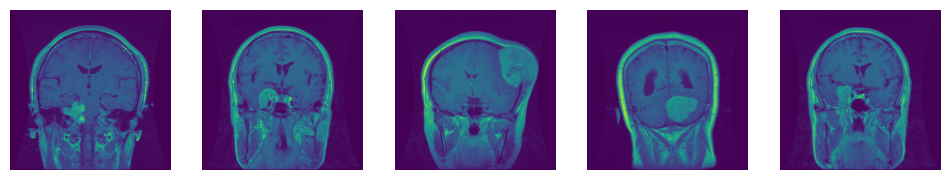

Glioma tumours:


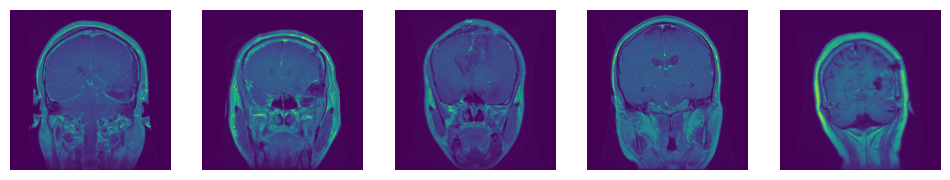

Pituitary tumours:


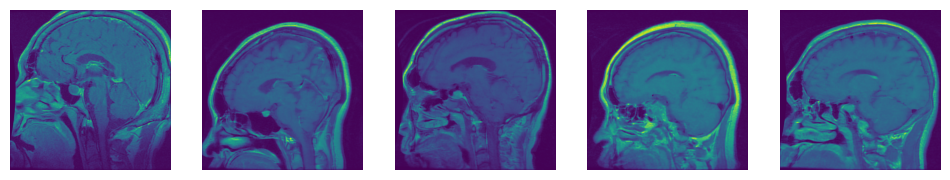

In [3]:
#=====================================================================================================================
# showing 5 examples of brain scans for each tumour type


# dataset.samples has the path and class index of every image, so this takes out all paths for class index 0
paths_idx_0 = [img for img, label in dataset.samples if label == 0] 
paths_idx_1 = [img for img, label in dataset.samples if label == 1] 
paths_idx_2 = [img for img, label in dataset.samples if label == 2] 

# putting into a list 
paths_list = [paths_idx_0, paths_idx_1, paths_idx_2]

for idx in range (len(tumour_type_idx)):
    
    plt.figure(figsize=(12, 3))
    print(tumour_type_idx[idx], "tumours:")
    
    for i in range(5):
        img = Image.open(paths_list[idx][i])
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()


In [4]:
#=====================================================================================================================
# orientation prediction model 
#=====================================================================================================================


# Collecting images for the three orientations: Sagittal (side view), Axial (top looking down) and Coronal (front or back view):

# Sagittal

# the file names are loosely related to the index by idx = filename - 2296
# there is a group of side view scans from 2455 (index 155) to 2706 (index 402)
sagittal_indices = []
for i in range(402-155):
    sagittal_indices.append(i+155)
sagittal_dataset = Subset(dataset, sagittal_indices)

# Axial  

# there's a group of axial images from 2760 (index 403) to 2943 (index 585)
axial_indices =[]
for i in range(585-403):
    axial_indices.append(i+403)
axial_dataset = Subset(dataset, axial_indices)

# Coronal 

# there's a group of coronal images from 2971 (index 611) to 3063 (index 703)
coronal_indices =[]
for i in range(703-611):
    coronal_indices.append(i+611)
# adding more coronal images to even out, there's a group at 1634 (index 2463) to 1784 (index 2613)
for i in range(2613-2463):
    coronal_indices.append(i+2463)
coronal_dataset = Subset(dataset, coronal_indices)


In [5]:
#=====================================================================================================================
# printing information on orientation subsets


# image filenames are not a perfect list, so indexing by (filename - 2296) won't be perfectly accurate
# printing the index and filenames together, I found the accurate indexes
# to double check, I've printed the image file for the index bounds

length_s=len(sagittal_indices)
print(f"Sagittal Subset: {length_s} images")
path_, label = dataset.samples[155]
print(f"Index: {155} Filename: {os.path.basename(path_)}")
print("--to--")
path_, label = dataset.samples[402]
print(f"Index: {402} Filename: {os.path.basename(path_)}")
print()
length_a=len(axial_indices)
print(f"Axial Subset: {length_a} images")
path_, label = dataset.samples[403]
print(f"Index: {403} Filename: {os.path.basename(path_)}")
print("--to--")
path_, label = dataset.samples[585]
print(f"Index: {585} Filename: {os.path.basename(path_)}")
print()
length_c=len(coronal_indices)
print(f"Coronal Subset: {length_c} images")
path_, label = dataset.samples[611]
print(f"Index: {611} Filename: {os.path.basename(path_)}")
print("--to--")
path_, label = dataset.samples[703]
print(f"Index: {703} Filename: {os.path.basename(path_)}")
print("and")
path_, label = dataset.samples[2613]
print(f"Index: {2613} Filename: {os.path.basename(path_)}")
print("--to--")
path_, label = dataset.samples[2463]
print(f"Index: {2463} Filename: {os.path.basename(path_)}")


Sagittal Subset: 247 images
Index: 155 Filename: 2455.png
--to--
Index: 402 Filename: 2706.png

Axial Subset: 182 images
Index: 403 Filename: 2760.png
--to--
Index: 585 Filename: 2943.png

Coronal Subset: 242 images
Index: 611 Filename: 2971.png
--to--
Index: 703 Filename: 3063.png
and
Index: 2613 Filename: 1784.png
--to--
Index: 2463 Filename: 1634.png


In [6]:
#=====================================================================================================================
# rewriting the labels for orientation, so that the model learns to distinguish orientation not tumour type 


# orientation index:  0: Sagittal  1: Axial  2: Coronal

# rewriting the label of the subsets so they the label is orientation not tumour type
sagittal_labeled = LabelreWrite(sagittal_dataset, 0)
axial_labeled = LabelreWrite(axial_dataset, 1)
coronal_labeled = LabelreWrite(coronal_dataset, 2)

# merging and loading the subsets
combined_orientation_data = ConcatDataset([axial_labeled, coronal_labeled, sagittal_labeled])

# train and test length with a 8:2 ratio
train_size = int(0.8 * len(combined_orientation_data))
test_size = len(combined_orientation_data) - train_size

# making the orientation model reproducable
seed = 9
torch.manual_seed(seed) # sets seed for CPU torch
torch.cuda.manual_seed_all(seed) # sets seed for GPU torch
torch.backends.cudnn.deterministic = True # line from Gemini
torch.backends.cudnn.benchmark = False # line from Gemini

seed_split = 7
generator = torch.Generator().manual_seed(seed_split)

# performing random split but with a set seed for reproducability
train_orient, test_orient = random_split(combined_orientation_data, [train_size, test_size], generator=generator)

# loading the train and test datasets
train_loader_orient = DataLoader(train_orient, batch_size=16, shuffle=True)
test_loader_orient = DataLoader(test_orient, batch_size=16, shuffle=False)

print()
print(f"Total dataset length: {len(combined_orientation_data)}")
print()
print("Train and Test data ratio 8:2")
print()
print(f"Train Dataset Length: {train_size}")
print(f"Test Dataset Length: {test_size}")
print()



Total dataset length: 671

Train and Test data ratio 8:2

Train Dataset Length: 536
Test Dataset Length: 135



In [7]:
#=====================================================================================================================
# training orientation model

# using a pre-trained model 
sorter_model = models.resnet18(weights='DEFAULT')

# changing the final layer output to 3 (sagittal, axial, coronal)
num_ftrs = sorter_model.fc.in_features
sorter_model.fc = nn.Linear(num_ftrs, 3) 

sorter_model = sorter_model.to(device)
# using same loss function as main models
loss_function = nn.CrossEntropyLoss() 

# optimizing the parameters after each epoch
optimizer = optim.Adam(sorter_model.parameters(), lr=0.001)

epoch_num=12

# training the model on the orientation subset data:
sorter_model.train()
for epoch in range(epoch_num):
    # resetting running loss to 0 each run
    running_loss = 0.0 
    for inputs, labels in train_loader_orient:
        # moving to GPU
        inputs = inputs.to(device)
        labels = labels.to(device)

        # clearing the gradient for each image
        optimizer.zero_grad()
        # model tries to predict orientation
        outputs = sorter_model(inputs)
        # calculating loss from prediction to actual orientation label
        loss = loss_function(outputs, labels)
        # calculating backwards what weights to use
        loss.backward()
        # updating weights
        optimizer.step()

        # adding the loss from each image to the loss for this epoch
        running_loss += loss.item()
    # adding loss to the list
    loss_epoch = running_loss/len(train_loader_orient)
        
    print(f"Epoch {epoch+1} Loss: {loss_epoch:.4f}")


Epoch 1 Loss: 0.1892
Epoch 2 Loss: 0.0470
Epoch 3 Loss: 0.1126
Epoch 4 Loss: 0.0542
Epoch 5 Loss: 0.0409
Epoch 6 Loss: 0.0247
Epoch 7 Loss: 0.0028
Epoch 8 Loss: 0.0009
Epoch 9 Loss: 0.0011
Epoch 10 Loss: 0.0031
Epoch 11 Loss: 0.0019
Epoch 12 Loss: 0.0019


In [8]:
#=====================================================================================================================
# evaluating the orientation model

sorter_model.eval()
correct_count = 0
incorrect_count = 0

orient_names = ['Sagittal', 'Axial', 'Coronal']


with torch.no_grad():
    for inputs, labels in test_loader_orient:
        # moving to GPU
        inputs = inputs.to(device)
        labels = labels.to(device)
        # model predicts orientation
        outputs = sorter_model(inputs)
        # the max probability is the model's prediction
        _, preds = torch.max(outputs, 1)

        # loop over the 3 prediction probabilities
        for i in range(len(preds)):
            true_view = orient_names[labels[i]]
            pred_view = orient_names[preds[i]]

            # correctly predicted orientation
            if preds[i] == labels[i]:
                correct_count += 1
                
            # incorrectly predicted orientation
            else:            
                incorrect_count += 1

accuracy = (correct_count / (correct_count+incorrect_count)) * 100
print()
print(f"Overall Orientation Prediction Accuracy: {accuracy:.2f}%")
print()



Overall Orientation Prediction Accuracy: 100.00%



In [9]:
#=====================================================================================================================
# using this model to predict the orientations of all the images in the dataset


sorter_model.eval()
all_orientations = []

with torch.no_grad():
    # loading the full brain scans dataset, no shuffle to keep the ordering
    full_loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False)
    
    for inputs, _ in full_loader:
        inputs = inputs.to(device)
        # probabilities of each orientation prediction
        outputs = sorter_model(inputs)
        # max probability is the model's prediction
        _, preds = torch.max(outputs, 1)
        # add to full list
        all_orientations.extend(preds.cpu().numpy())

# all_orientations is now a list of 3064 numbers (0, 1, or 2) 
# matching the exact order of the dataset

# saving the map
torch.save(all_orientations, 'orientation_list.pt')
print(f"Model predicted orientations dataset length: {len(all_orientations)}")
print(f"Dataset length: {len(dataset)}")


Model predicted orientations dataset length: 3064
Dataset length: 3064



Orientations:
Sagittal (side view), Axial (top looking down), Coronal (front or back view)



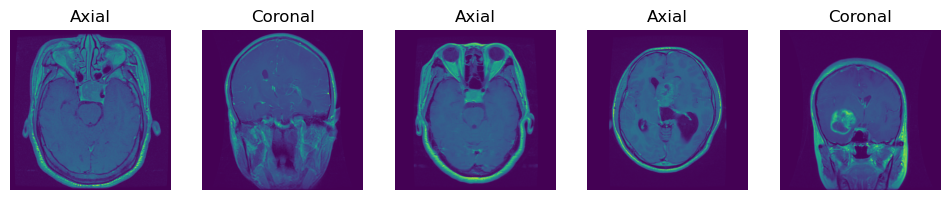

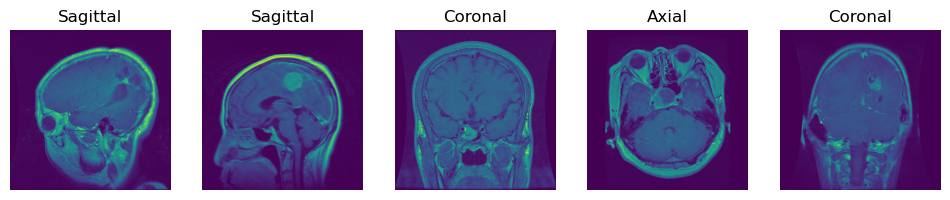

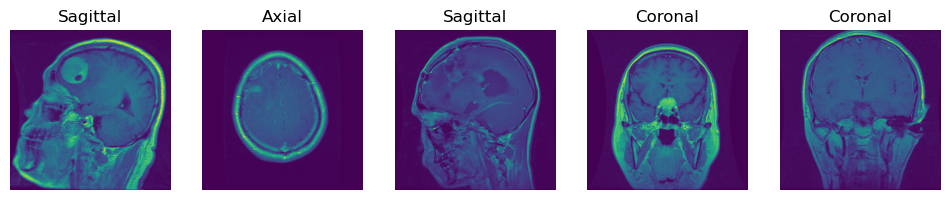

In [10]:
#=====================================================================================================================
# printing 15 random images with their predicted orientation to demonstrate the model

print()
print("Orientations:")
print("Sagittal (side view), Axial (top looking down), Coronal (front or back view)")
print()
for m in range(3):
    plt.figure(figsize=(12, 3))

    for i in range(5):
        num = random.randint(1, 3064)
        img_path = dataset.samples[num][0]
        label = dataset.samples[num][1]
        orientation = all_orientations[num]
        img = Image.open(img_path)
        plt.subplot(1, 5, i+1)
        plt.title(orient_names[orientation])
        plt.imshow(img)
        plt.axis("off")
    plt.show



Number of orientations of brain scan for each type of tymour:

Meningioma Tumours
-----------
Sagittal, 268
Axial, 209
Coronal, 231

Glioma Tumours
-----------
Sagittal, 332
Axial, 425
Coronal, 669

Pituitary Tumours
-----------
Sagittal, 433
Axial, 362
Coronal, 135



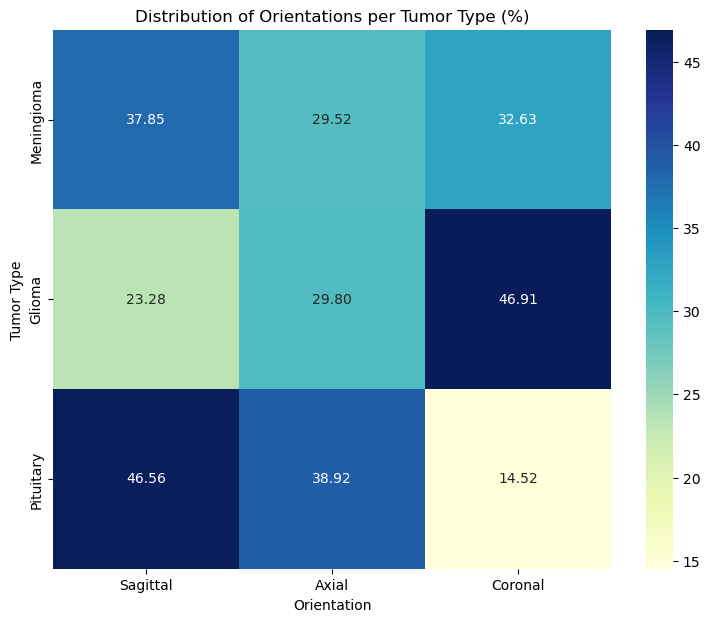

In [15]:
#=====================================================================================================================
# printing how many of each orientation are in each tumour folder


matrix_numbers = [[0,0,0], [0,0,0], [0,0,0]]
# the big three are the tumour types
# the numbers within are the number of each orientation within the tymour type

# num is the number along the total list of all images, to index all_orientations
num=0

# loop over tumour classes
for folder in os.listdir(path):
    folder_path = os.path.join(path, folder)
    # skip .DS_Store hidden folder again
    if not os.path.isdir(folder_path):
        continue

    # images is all the images in a tumour folder
    images = os.listdir(folder_path)

    for file_name in images:

        tumour_idx = int(folder)-1
        # finding model predicted orientation from the images index in the full list
        orient = all_orientations[num]
        # adding 1 to the specific tumour type and orientation in the matrix_numbers
        matrix_numbers[tumour_idx][orient] += 1
        # moving index up one for the next image
        num+=1


print()
print("Number of orientations of brain scan for each type of tymour:")
print()
# loop over the three tumour types
for i in range(3):
    print(f"{tumour_type_idx[i]} Tumours")
    print("-----------")
    # printing each orientation and the number of them
    for j in range(3):
        print(f"{orient_names[j]}, {matrix_numbers[i][j]}")
    print()

matrix_numbers_norm = [[0,0,0], [0,0,0], [0,0,0]]

# normalising so that each row in the matrix sums to 100%
for i in range(3):
    sum_ = sum(matrix_numbers[i])
    for j in range(3):
        perc=matrix_numbers[i][j]/sum_ *100
        perc = round(perc, 2)
        matrix_numbers_norm[i][j]=perc

# turning my nested list into a dataframe to use the heatmap
df_orientation = pd.DataFrame(matrix_numbers_norm,index=tumour_type_idx,columns=orient_names)

plt.figure(figsize=(9, 7))
sns.heatmap(df_orientation, annot=True, fmt='.2f', cmap='YlGnBu', cbar=True)

plt.title('Distribution of Orientations per Tumor Type (%)')
plt.xlabel('Orientation')
plt.ylabel('Tumor Type')
plt.show()


In [16]:
#=====================================================================================================================
# adding orientation to the dataset and loading the data


# determining the size of train and test data
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

# splitting the data into test and train
train_ds, test_ds = random_split(dataset, [train_size,test_size])

# adding orientation to the train and test datasets
train_multi = OrientIndexAddOn(train_ds, all_orientations)
test_multi  = OrientIndexAddOn(test_ds, all_orientations)

train_loader_orient_model = torch.utils.data.DataLoader(train_multi, batch_size=32, shuffle=True)
test_loader_orient_model  = torch.utils.data.DataLoader(test_multi, batch_size=32, shuffle=False)


print()
print("Test and Train data split:")
print()
train_perc = train_size/(train_size+test_size) *100
test_perc = 100 - train_perc
print(f"Train Data: {train_perc:.2f}%, {train_size} images")
print(f"Test Data: {test_perc:.2f}%, {test_size} images")
print()


Test and Train data split:

Train Data: 79.99%, 2451 images
Test Data: 20.01%, 613 images



In [17]:
#=====================================================================================================================
# CNN 1: Main model for identifying tumour type (with orienation) 
#====================================================================================================================

# create the model
model_orient = CNN_orient().to(device)

# inputting loaded train and test datasets into the trainer 
trainer = Trainer(model=model_orient, n_epochs=35, lr=1e-4, train_loader=train_loader_orient_model, test_loader=test_loader_orient_model, device=device, patience=5, min_delta=0.0)

# fitting the CNN to the datasets, saving the weights after fitting
trainer.fit(weight_saved_name = 'CNN_1_weights')

# epochs printed below:

Epoch [1/35]  train_loss: 0.8970  val_loss: 0.5908
Epoch [2/35]  train_loss: 0.6035  val_loss: 0.5367
Epoch [3/35]  train_loss: 0.5467  val_loss: 0.4956
Epoch [4/35]  train_loss: 0.4969  val_loss: 0.4707
Epoch [5/35]  train_loss: 0.4722  val_loss: 0.4512
Epoch [6/35]  train_loss: 0.4578  val_loss: 0.4342
Epoch [7/35]  train_loss: 0.4279  val_loss: 0.4259
Epoch [8/35]  train_loss: 0.3974  val_loss: 0.4135
Epoch [9/35]  train_loss: 0.3864  val_loss: 0.3921
Epoch [10/35]  train_loss: 0.3760  val_loss: 0.3867
Epoch [11/35]  train_loss: 0.3493  val_loss: 0.3819
Epoch [12/35]  train_loss: 0.3413  val_loss: 0.3666
Epoch [13/35]  train_loss: 0.3230  val_loss: 0.3451
Epoch [14/35]  train_loss: 0.3164  val_loss: 0.3481
Epoch [15/35]  train_loss: 0.3053  val_loss: 0.3421
Epoch [16/35]  train_loss: 0.3017  val_loss: 0.3459
Epoch [17/35]  train_loss: 0.2918  val_loss: 0.3466
Epoch [18/35]  train_loss: 0.2743  val_loss: 0.3402
Epoch [19/35]  train_loss: 0.2760  val_loss: 0.3274
Epoch [20/35]  train_

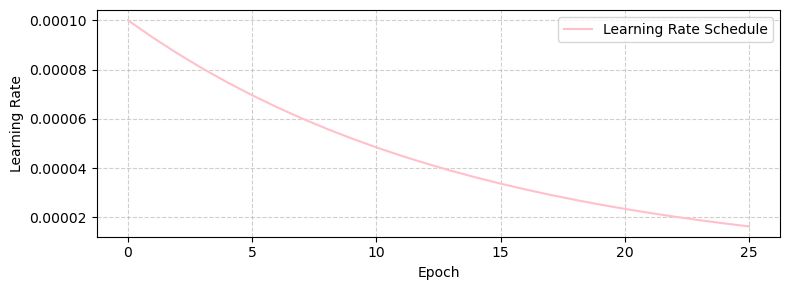

In [18]:
#====================================================================================================================
# plotting the learning rate changing from optimisation to visualise it

x_axis = np.arange(0, 26)
y_axis = []
lr_original = 0.0001

for i in x_axis:
    opt_train = lr_original*(0.93**(i))
    y_axis.append(opt_train)

plt.figure(figsize=(8, 3))
plt.plot(x_axis, y_axis, label="Learning Rate Schedule", color='pink')
plt.autoscale(enable=True, axis='both')
plt.ylabel("Learning Rate")
plt.grid(True, linestyle='--', alpha=0.6) # adding a grid to look more professional
plt.legend()
plt.xlabel("Epoch")
plt.legend()
plt.tight_layout()
#plt.savefig("optimiser_plot.pdf")
plt.show()


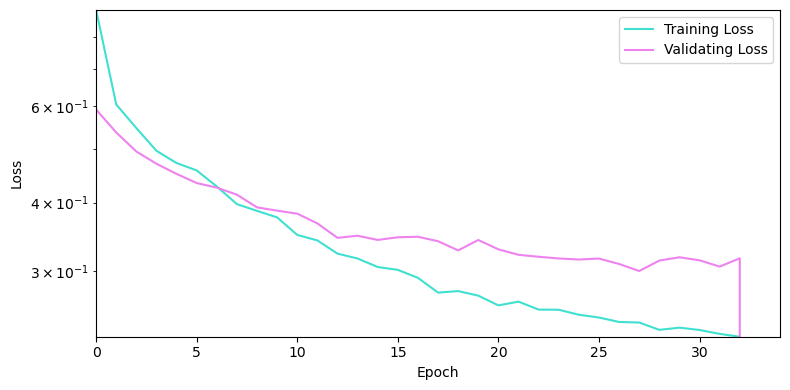

In [19]:
#====================================================================================================================
# Plotting training and validation loss with epoch to visualise learning

x = np.arange(0,trainer.n_epochs)

plt.figure(figsize=(8, 4))
plt.plot(x, trainer.loss_train, label="Training Loss", color = 'turquoise')
plt.plot(x, trainer.loss_val, label="Validating Loss", color = 'violet')
plt.autoscale(enable=True, axis='both', tight=True)
plt.yscale('log')
plt.xlabel("Epoch")

plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
#plt.savefig("loss_main_model.pdf")
plt.show()


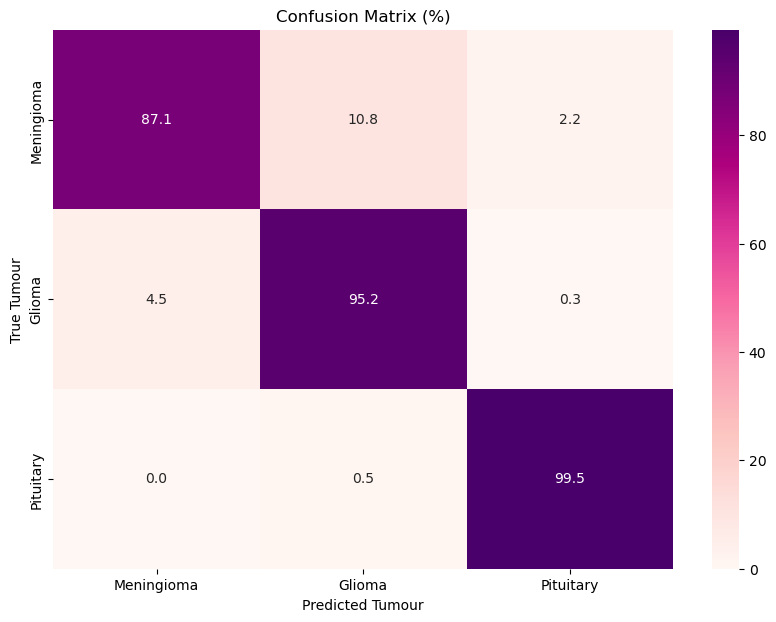

In [20]:
#====================================================================================================================
# Confusion Plot of true and false oredicted tumour type

# evaluate the model
model_orient.eval()

# actual tumour type
type_true = []

# model predicted tumour type
type_pred = []

with torch.no_grad():
    # loop over each batch of size 32
    for batch in test_loader_orient_model:
        
        # x: image, y: tumour index, orientations: orientation index
        x, y, orientations = batch
        
        x = x.to(device)
        orientations = orientations.to(device)
        
        # model takes in the image and the orientation 
        logits = model_orient(x, orientations)
        pred = torch.argmax(logits, dim=1).detach().cpu().numpy()

        # adding true and predicted tumour type to the lists
        type_true.extend(y.cpu().numpy().tolist())
        type_pred.extend(pred.tolist())


# confusion matrix of lists of true and predicted tumour type
cm = confusion_matrix(type_true, type_pred)

# turning type_true and type_pred to percentages 
# normalising each row with axis=1, so each row is total 100% of the given tumor type
# so the row values show what percentage are identified as each tumour type
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# plotting the percentage confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm_perc, annot=True, fmt='.1f', cmap='RdPu', 
            xticklabels=tumour_type_idx, 
            yticklabels=tumour_type_idx)

plt.xlabel('Predicted Tumour')
plt.ylabel('True Tumour')
plt.title('Confusion Matrix (%)')
#plt.savefig("confusion_matrix.pdf")
plt.show()


In [21]:
#====================================================================================================================
# Printing the size of the validation dataset and true and false prediction rate

n = len(type_true)
print()
print(f"Number of test images: {n}")
print()

# true prediction rate is the trace of the confusion matrix
n_tp = np.trace(cm)
tpr = n_tp/n*100
fpr = (1-(n_tp/n))*100
print(f"True prediction rate: {tpr:.2f}%")

n_fp = n - n_tp
print(f"False prediction rate: {fpr:.2f}%")
print()



Number of test images: 613

True prediction rate: 94.62%
False prediction rate: 5.38%



In [22]:
#====================================================================================================================
# confidence analysis

calculate_model_confidence(model=CNN_orient, data_loader=test_loader_orient_model, device=device, weight_saved_name='CNN_1_weights', orient=True)

Average probability on correct predictions: 92.40
Average probability on incorrect predictions: 72.59


In [23]:
#=====================================================================================================================
# CNN 2: Main model for identifying tumour type (without orienation)
#====================================================================================================================

# dataset without orientation isalready made as train_ds and test_ds before it was wrapped with orientation index
train_loader_no_orient = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader_no_orient  = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)

# creating the model
model_no_orient = CNN_no_orient().to(device)

# loading the trainer
trainer_no_orient = Trainer(model=model_no_orient, n_epochs=35, lr=1e-4, train_loader=train_loader_no_orient, test_loader=test_loader_no_orient, device=device, patience=5, min_delta=0.0)

# fitting h=the model to the training dataset
trainer_no_orient.fit(weight_saved_name = 'CNN_2_weights')

# epochs below!

Epoch [1/35]  train_loss: 0.9550  val_loss: 0.8359
Epoch [2/35]  train_loss: 0.8192  val_loss: 0.7588
Epoch [3/35]  train_loss: 0.7783  val_loss: 0.8071
Epoch [4/35]  train_loss: 0.7494  val_loss: 0.7277
Epoch [5/35]  train_loss: 0.7190  val_loss: 0.7363
Epoch [6/35]  train_loss: 0.7119  val_loss: 0.7012
Epoch [7/35]  train_loss: 0.6852  val_loss: 0.6840
Epoch [8/35]  train_loss: 0.6752  val_loss: 0.6868
Epoch [9/35]  train_loss: 0.6537  val_loss: 0.6736
Epoch [10/35]  train_loss: 0.6374  val_loss: 0.6892
Epoch [11/35]  train_loss: 0.6308  val_loss: 0.6456
Epoch [12/35]  train_loss: 0.6231  val_loss: 0.6497
Epoch [13/35]  train_loss: 0.6151  val_loss: 0.6516
Epoch [14/35]  train_loss: 0.5998  val_loss: 0.6344
Epoch [15/35]  train_loss: 0.5970  val_loss: 0.6364
Epoch [16/35]  train_loss: 0.5866  val_loss: 0.6339
Epoch [17/35]  train_loss: 0.5832  val_loss: 0.6314
Epoch [18/35]  train_loss: 0.5775  val_loss: 0.6253
Epoch [19/35]  train_loss: 0.5710  val_loss: 0.6179
Epoch [20/35]  train_

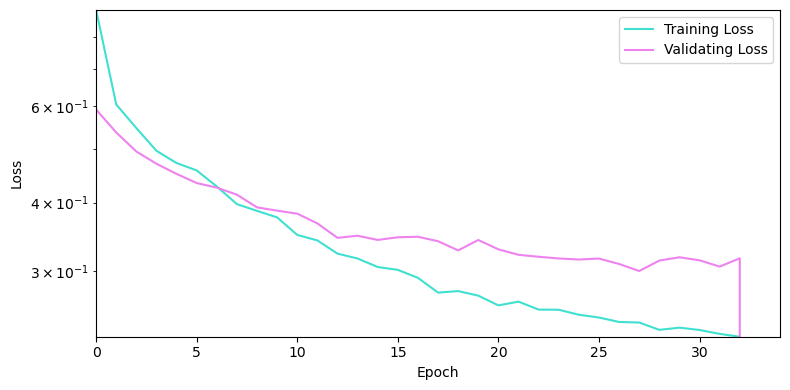

In [24]:
#====================================================================================================================
# plotting training and validation loss with epoch to visualise the model's learning 

x = np.arange(0,trainer_no_orient.n_epochs)

plt.figure(figsize=(8, 4))
plt.plot(x, trainer.loss_train, label="Training Loss", color = 'turquoise')
plt.plot(x, trainer.loss_val, label="Validating Loss", color = 'violet')
plt.autoscale(enable=True, axis='both', tight=True)
plt.yscale('log')
plt.xlabel("Epoch")

plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
#plt.savefig("loss_no_orient_model.pdf")
plt.show()


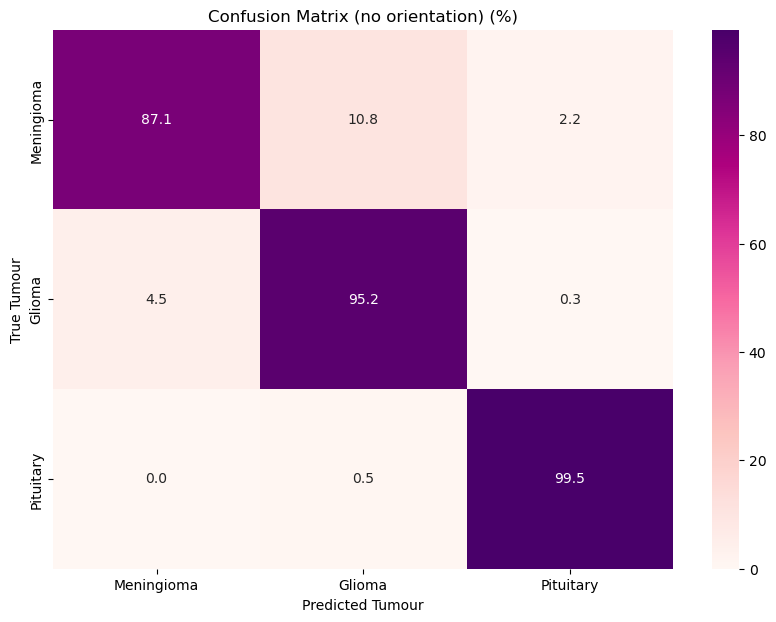

In [25]:
#====================================================================================================================
# confusion plot of true tumour type and model predicted tumour type

# evaluating the model
model_no_orient.eval()

# actual tumour type
type_true_ = []
# model predicted tumour type
type_pred_ = []
with torch.no_grad():
    for batch in test_loader_no_orient:
        
        # x: image, y: tumour index, no orientation index.
        x, y = batch
        
        x = x.to(device)
        
        # model takes in the image and the orientation 
        logits = model_no_orient(x)
        pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
        type_true_.extend(y.cpu().numpy().tolist())
        type_pred_.extend(pred.tolist())


# confusion matrix of raw numbers
cm_ = confusion_matrix(type_true_, type_pred_)

# turning type_true and type_pred to percentages 
# normalising each row with axis=1, so each row is total 100% of the given tumor type
# so the row values show what percentage are identified as each tumour type
cm_perc_ = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# plotting the percentage confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm_perc, annot=True, fmt='.1f', cmap='RdPu', 
            xticklabels=tumour_type_idx, 
            yticklabels=tumour_type_idx)

plt.xlabel('Predicted Tumour')
plt.ylabel('True Tumour')
plt.title('Confusion Matrix (no orientation) (%)')
#plt.savefig("confusion_matrix_no_orient.pdf")
plt.show()

In [26]:
#====================================================================================================================
# true and false prediction rate calculation

n = len(type_true_)
print()
print(f"Number of test images: {n}")
print()

n_tp = np.trace(cm_)
tpr = n_tp/n*100
fpr = (1-(n_tp/n))*100
print(f"True prediction rate: {tpr:.2f}%")

n_fp = n - n_tp
print(f"False prediction rate: {fpr:.2f}%")
print()


Number of test images: 613

True prediction rate: 61.83%
False prediction rate: 38.17%



In [27]:
#====================================================================================================================
# Confidence Analysis

calculate_model_confidence(model=CNN_no_orient, data_loader=test_loader_no_orient, device=device, weight_saved_name='CNN_2_weights', orient=False)

Average probability on correct predictions: 90.07
Average probability on incorrect predictions: 40.73
